In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

In [3]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/massachusetts-buildings-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.49G/1.49G [00:12<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2


In [5]:
import shutil

drive_dataset_path = "/content/gdrive/MyDrive/building_dataset"

shutil.copytree(
    path,
    drive_dataset_path,
    dirs_exist_ok=True
)

print("Dataset copied.")

Dataset copied.


In [6]:
dataset_path = "/content/gdrive/MyDrive/building_dataset"

for root, dirs, files in os.walk(dataset_path):

    print("\nFOLDER:", root)

    print("Subfolders:", dirs[:5])

    print("Sample files:", files[:5])

    print("-" * 50)


FOLDER: /content/gdrive/MyDrive/building_dataset
Subfolders: ['tiff', 'png']
Sample files: ['metadata.csv', 'label_class_dict.csv']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/building_dataset/tiff
Subfolders: ['test', 'val_labels', 'train', 'val', 'test_labels']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/building_dataset/tiff/test
Subfolders: []
Sample files: ['23429080_15.tiff', '22828930_15.tiff', '22829050_15.tiff', '23879080_15.tiff', '23579005_15.tiff']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/building_dataset/tiff/val_labels
Subfolders: []
Sample files: ['23579050_15.tif', '22978945_15.tif', '23429155_15.tif', '23728930_15.tif']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/building_dataset/tiff/train
Subfolders: []
Sample files: ['23578990_15.tiff', '24478840_15.tiff', '23429170_15.tiff', '22678960_15

Sample file: 22678915_15.png


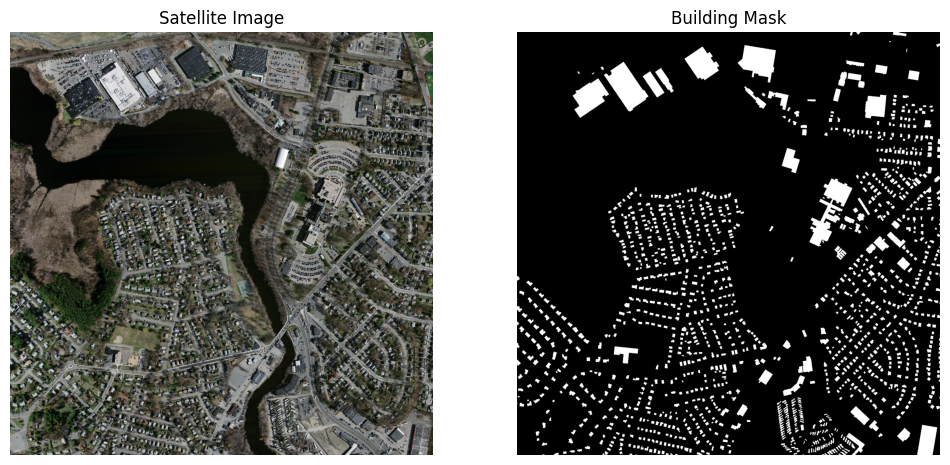

In [7]:
image_dir = dataset_path + "/png/train"
mask_dir = dataset_path + "/png/train_labels"

image_files = sorted(os.listdir(image_dir))

sample_file = image_files[0]

print("Sample file:", sample_file)

img_path = os.path.join(image_dir, sample_file)
mask_path = os.path.join(mask_dir, sample_file)

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Satellite Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Building Mask")
plt.axis("off")

plt.show()

In [8]:
train_image_dir = dataset_path + "/png/train"
train_mask_dir = dataset_path + "/png/train_labels"

train_pairs = []

for file_name in os.listdir(train_image_dir):

    image_path = os.path.join(train_image_dir, file_name)
    mask_path = os.path.join(train_mask_dir, file_name)

    if os.path.exists(mask_path):

        train_pairs.append((image_path, mask_path))

print("Training pairs:", len(train_pairs))

print("\nSample pair:")
print(train_pairs[0])

Training pairs: 137

Sample pair:
('/content/gdrive/MyDrive/building_dataset/png/train/23579020_15.png', '/content/gdrive/MyDrive/building_dataset/png/train_labels/23579020_15.png')


In [9]:
val_image_dir = dataset_path + "/png/val"
val_mask_dir = dataset_path + "/png/val_labels"

val_pairs = []

for file_name in os.listdir(val_image_dir):

    image_path = os.path.join(val_image_dir, file_name)
    mask_path = os.path.join(val_mask_dir, file_name)

    if os.path.exists(mask_path):

        val_pairs.append((image_path, mask_path))

print("Validation pairs:", len(val_pairs))

Validation pairs: 4


In [10]:
processor = SegformerImageProcessor(
    do_reduce_labels=False
)

In [11]:
class BuildingDataset(Dataset):

    def __init__(self, pairs, processor):

        self.pairs = pairs
        self.processor = processor

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, mask_path = self.pairs[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image)
        mask = np.array(mask)

        # Binary mask
        mask = (mask > 0).astype(np.uint8)

        encoding = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        pixel_values = encoding["pixel_values"].squeeze()
        labels = encoding["labels"].squeeze()

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

In [12]:
train_dataset = BuildingDataset(train_pairs, processor)
val_dataset = BuildingDataset(val_pairs, processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2
)

print("Building datasets ready.")

Building datasets ready.


In [13]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("Building model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Building model loaded.


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print(device)

cuda


In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5
)

In [16]:
from tqdm import tqdm

model.train()

EPOCHS = 5

for epoch in range(EPOCHS):

    total_loss = 0

    loop = tqdm(train_loader)

    for batch in loop:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 69/69 [00:44<00:00,  1.54it/s, loss=0.616]



Epoch 1 Average Loss: 0.6867


Epoch 2: 100%|██████████| 69/69 [00:28<00:00,  2.44it/s, loss=0.484]



Epoch 2 Average Loss: 0.4900


Epoch 3: 100%|██████████| 69/69 [00:28<00:00,  2.46it/s, loss=0.414]



Epoch 3 Average Loss: 0.4006


Epoch 4: 100%|██████████| 69/69 [00:27<00:00,  2.50it/s, loss=0.398]



Epoch 4 Average Loss: 0.3601


Epoch 5: 100%|██████████| 69/69 [00:30<00:00,  2.29it/s, loss=0.269]


Epoch 5 Average Loss: 0.3362


In [17]:
test_image_path = val_pairs[0][0]

print(test_image_path)

/content/gdrive/MyDrive/building_dataset/png/val/23429155_15.png


In [18]:
model.eval()

image = Image.open(test_image_path).convert("RGB")

image_np = np.array(image)

inputs = processor(
    images=image_np,
    return_tensors="pt"
)

pixel_values = inputs["pixel_values"].to(device)

with torch.no_grad():

    outputs = model(pixel_values=pixel_values)

logits = outputs.logits

pred_mask = torch.argmax(
    logits,
    dim=1
).squeeze().cpu().numpy()

In [19]:
pred_mask = cv2.resize(
    pred_mask.astype(np.uint8),
    (image_np.shape[1], image_np.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

In [20]:
overlay = image_np.copy()

# Buildings = red
overlay[pred_mask == 1] = [255, 0, 0]

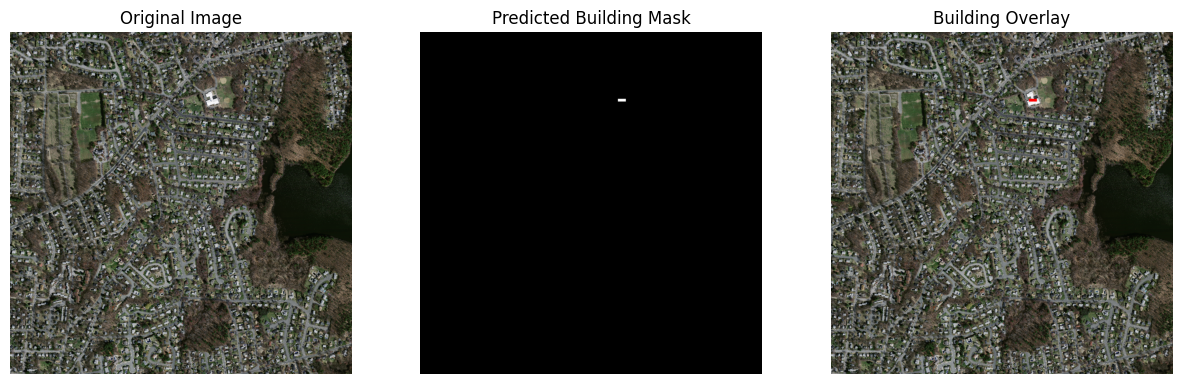

In [21]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Building Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Building Overlay")
plt.axis("off")

plt.show()

In [22]:
building_pixels = np.sum(pred_mask == 1)

total_pixels = pred_mask.size

building_percent = (
    building_pixels / total_pixels
) * 100

print(
    "Building Coverage:",
    round(building_percent, 2),
    "%"
)

Building Coverage: 0.02 %


In [23]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    pred_mask.astype(np.uint8),
    connectivity=8
)

building_count = 0

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > 30:
        building_count += 1

print("Estimated Buildings:", building_count)

Estimated Buildings: 1


In [24]:
alerts = []

if building_percent > 35:
    alerts.append(
        "High urban density region detected."
    )

if building_count > 100:
    alerts.append(
        "Dense infrastructure cluster identified."
    )

print("Alerts:\n")

for alert in alerts:
    print("-", alert)

Alerts:



In [25]:
from PIL import Image

overlay_image = Image.fromarray(overlay)

overlay_image.save("building_overlay_result.png")

print("Overlay saved.")

Overlay saved.


In [26]:
torch.save(
    model.state_dict(),
    "building_segformer.pth"
)

print("Building model saved.")

Building model saved.


In [27]:
torch.save(
    model.state_dict(),
    "/content/gdrive/MyDrive/building_segformer.pth"
)

print("Model backed up.")

Model backed up.


In [28]:
from google.colab import files

files.download("building_segformer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>